# Question C：使用梯度提升预测正向市场走势

本题基于第 2 题筛选出的特征，建立、调参并评估一个用于预测沪深 300 指数下一交易日有效上涨的梯度提升模型。

## 建模设计

目标变量为二分类标签：如果下一交易日对数收益率大于 0.15%，则为 1；否则为 0。这个定义使“上涨”不是简单的大于零，而是剔除了非常接近零的小幅波动。

模型采用 `XGBoostClassifier`。选择 XGBoost 的原因是它能够处理非线性关系和特征交互，并且内置正则化、列采样和行采样，适合金融数据中噪声较高、信号较弱的场景。

In [11]:
from pathlib import Path
import os
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import ConfusionMatrixDisplay, RocCurveDisplay

plt.rcParams["font.sans-serif"] = ["Microsoft YaHei", "SimHei", "Arial Unicode MS", "DejaVu Sans"]
plt.rcParams["axes.unicode_minus"] = False

# 允许 notebook 从项目根目录或 Exam3 目录运行。
if Path.cwd().name != "Exam3" and (Path.cwd() / "Exam3").exists():
    os.chdir(Path.cwd() / "Exam3")
if str(Path.cwd()) not in sys.path:
    sys.path.insert(0, str(Path.cwd()))

from workflow_draft import (
    WorkflowConfig,
    build_features,
    train_test_split_time,
    feature_selection_funnel,
    regularized_xgb,
    evaluate_classifier,
    tune_xgb,
    backtest_signal,
)

config = WorkflowConfig(data_path=Path("CSI300_2005_2026.csv"))
config

WorkflowConfig(data_path=WindowsPath('CSI300_2005_2026.csv'), start_date='2010-01-01', target_threshold=0.0015, test_size=0.2, random_state=42, cv_splits=5, cv_gap=1)

In [12]:
data, feature_cols = build_features(config)
X_train, X_test, y_train, y_test, train_frame, test_frame = train_test_split_time(
    data, feature_cols, config
)
selection = feature_selection_funnel(X_train, y_train, config)
final_features = selection["final_features"]

modeling_summary = pd.DataFrame({
    "项目": [
        "样本起止", "训练集起止", "测试集起止",
        "训练集样本数", "测试集样本数", "原始特征数", "最终特征数",
        "训练集正类比例", "测试集正类比例",
    ],
    "数值": [
        f"{data.index.min().date()} 至 {data.index.max().date()}",
        f"{train_frame.index.min().date()} 至 {train_frame.index.max().date()}",
        f"{test_frame.index.min().date()} 至 {test_frame.index.max().date()}",
        len(train_frame), len(test_frame), len(feature_cols), len(final_features),
        round(y_train.mean(), 4), round(y_test.mean(), 4),
    ],
})
modeling_summary

,项目,数值
0,样本起止,2010-01-04 至 2026-05-18
1,训练集起止,2010-01-04 至 2023-02-02
2,测试集起止,2023-02-03 至 2026-05-18
3,训练集样本数,3119
4,测试集样本数,780
5,原始特征数,75
6,最终特征数,15
7,训练集正类比例,0.4431
8,测试集正类比例,0.4179


## 基准模型

先使用一组保守的正则化 XGBoost 参数训练基准模型。由于训练集正负样本比例并非完全相等，模型使用 `scale_pos_weight` 处理类别不平衡。决策阈值不直接固定为 0.5，而是在训练集上用 Youden J 统计量选择，然后应用到测试集。

In [13]:
base_model = regularized_xgb(y_train, config)
base_eval = evaluate_classifier(
    base_model,
    X_train[final_features],
    y_train,
    X_test[final_features],
    y_test,
)

base_metrics = pd.DataFrame({
    "指标": ["训练集 AUC", "测试集 AUC", "Accuracy", "Balanced Accuracy", "决策阈值"],
    "数值": [
        base_eval["train_auc"], base_eval["test_auc"], base_eval["accuracy"],
        base_eval["balanced_accuracy"], base_eval["threshold"],
    ],
})
base_metrics["数值"] = base_metrics["数值"].round(4)
base_metrics

,指标,数值
0,训练集 AUC,0.6579
1,测试集 AUC,0.5730
2,Accuracy,0.5679
3,Balanced Accuracy,0.5389
4,决策阈值,0.5047


## 超参数调优

调优在训练集内部完成，使用 `TimeSeriesSplit(n_splits=5, gap=1)`，评分指标为 ROC AUC。搜索的超参数包括树数量、树深度、学习率、行采样、列采样、最小子节点权重、gamma、L1 和 L2 正则化。整个过程完全在本地运行，不使用 Colab 或 W&B。

In [14]:
search = tune_xgb(X_train[final_features], y_train, config, n_iter=50)

best_params = pd.DataFrame({
    "参数": list(search.best_params_.keys()),
    "最优值": list(search.best_params_.values()),
})
print(f"训练集时间序列交叉验证最佳 ROC AUC: {search.best_score_:.4f}")
best_params

训练集时间序列交叉验证最佳 ROC AUC: 0.5729


,参数,最优值
0,colsample_bytree,0.821128
1,gamma,1.779061
2,learning_rate,0.028380
3,max_depth,2.000000
4,min_child_weight,10.000000
5,n_estimators,72.000000
6,reg_alpha,0.000251
7,reg_lambda,0.509655
8,subsample,0.851158


In [ ]:
tuned_eval = evaluate_classifier(
    search.best_estimator_,
    X_train[final_features],
    y_train,
    X_test[final_features],
    y_test,
)

tuned_metrics = pd.DataFrame({
    "指标": ["训练集 AUC", "测试集 AUC", "Accuracy", "Balanced Accuracy", "决策阈值"],
    "数值": [
        tuned_eval["train_auc"], tuned_eval["test_auc"], tuned_eval["accuracy"],
        tuned_eval["balanced_accuracy"], tuned_eval["threshold"],
    ],
})
tuned_metrics["数值"] = tuned_metrics["数值"].round(4)
tuned_metrics

## 预测质量评估

ROC AUC 衡量模型对正负样本排序的能力。AUC 大于 0.5 说明模型在测试集上优于随机排序，但数值并不高，符合短期指数收益难以预测的现实。混淆矩阵和分类报告进一步展示了模型在 0/1 两类上的错误结构。

In [15]:
print("Confusion matrix [[TN, FP], [FN, TP]]:")
print(tuned_eval["confusion_matrix"])
print()
print("Classification report:")
print(tuned_eval["classification_report"])

Confusion matrix [[TN, FP], [FN, TP]]:
[[263 191]
 [165 161]]

Classification report:
              precision    recall  f1-score   support

           0      0.614     0.579     0.596       454
           1      0.457     0.494     0.475       326

    accuracy                          0.544       780
   macro avg      0.536     0.537     0.536       780
weighted avg      0.549     0.544     0.546       780



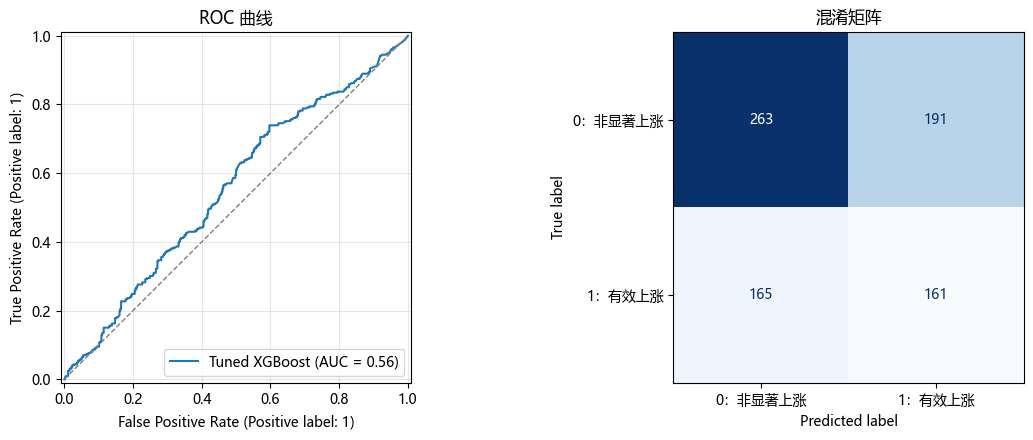

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

RocCurveDisplay.from_predictions(
    y_test,
    tuned_eval["test_proba"],
    ax=axes[0],
    name="Tuned XGBoost",
    color="#1f77b4",
)
axes[0].plot([0, 1], [0, 1], linestyle="--", color="gray", linewidth=1)
axes[0].set_title("ROC 曲线")
axes[0].grid(True, alpha=0.3)

ConfusionMatrixDisplay(
    confusion_matrix=tuned_eval["confusion_matrix"],
    display_labels=["0：非显著上涨", "1：有效上涨"],
).plot(ax=axes[1], colorbar=False, cmap="Blues")
axes[1].set_title("混淆矩阵")

plt.tight_layout()
plt.show()

## 特征重要性

下图展示调参后模型的 gain importance。重要性较高的特征包括短期均线偏离、MACD、近期极端收益、成交量标准化、RSI 和日内价格结构等。这说明模型主要从短期趋势、反转压力、波动状态和交易活跃度中提取信号。

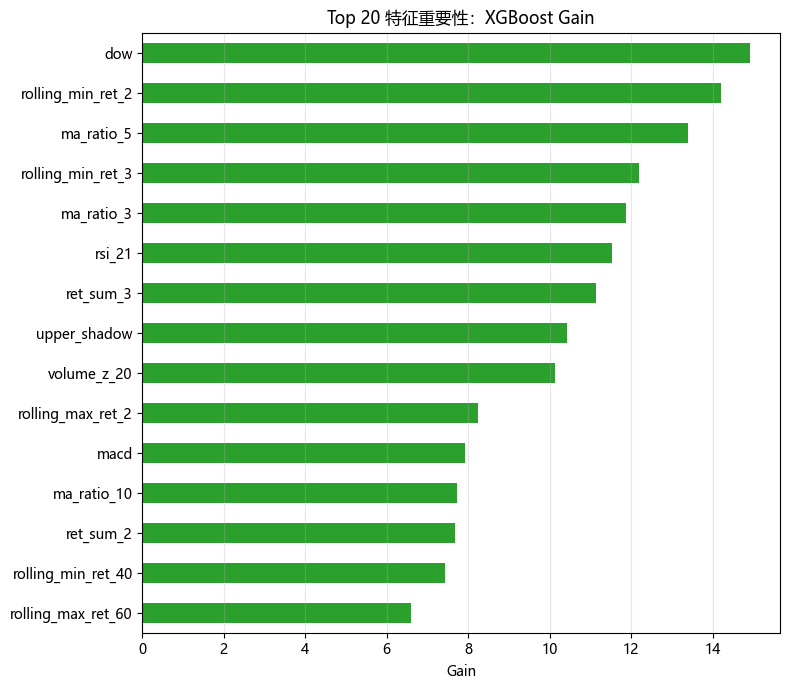

,gain
dow,14.9097
rolling_min_ret_2,14.2125
ma_ratio_5,13.4021
rolling_min_ret_3,12.1900
ma_ratio_3,11.8767
rsi_21,11.5211
ret_sum_3,11.1262
upper_shadow,10.4256
volume_z_20,10.1204
rolling_max_ret_2,8.2320


In [17]:
booster = tuned_eval["model"].get_booster()
score = booster.get_score(importance_type="gain")
importance = (
    pd.Series(score, name="gain")
    .reindex(final_features)
    .fillna(0)
    .sort_values(ascending=False)
)

fig, ax = plt.subplots(figsize=(8, 7))
importance.head(20).sort_values().plot(kind="barh", ax=ax, color="#2ca02c")
ax.set_title("Top 20 特征重要性：XGBoost Gain")
ax.set_xlabel("Gain")
ax.grid(True, axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

importance.head(20).round(4).to_frame()

## 可选回测：将预测信号用于简单交易策略

作为附加分析，构造一个简单多头策略：当模型预测为 1 时持有沪深 300，当模型预测为 0 时空仓。该回测不考虑交易成本、滑点和资金约束，因此只能作为预测信号经济意义的初步检验。

In [18]:
backtest = backtest_signal(test_frame, tuned_eval["y_pred"])
backtest.round(4)

,strategy,buy_hold
total_return,0.1835,-0.0103
annual_return,0.0560,-0.0033
annual_volatility,0.1056,0.1522
sharpe,0.5297,-0.0220
max_drawdown,-0.1246,-0.2663
exposure,0.4513,1.0000


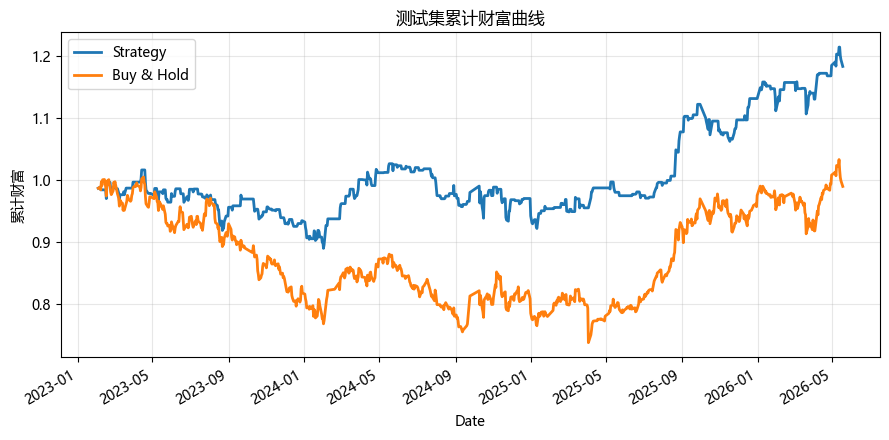

In [19]:
signal = pd.Series(tuned_eval["y_pred"], index=test_frame.index, name="signal")
strategy_returns = signal * test_frame["next_log_ret"]
buy_hold_returns = test_frame["next_log_ret"]

wealth = pd.DataFrame({
    "Strategy": np.exp(strategy_returns.cumsum()),
    "Buy & Hold": np.exp(buy_hold_returns.cumsum()),
})

fig, ax = plt.subplots(figsize=(9, 4.5))
wealth.plot(ax=ax, linewidth=2)
ax.set_title("测试集累计财富曲线")
ax.set_ylabel("累计财富")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 结论

调参后的 XGBoost 在测试集上的 ROC AUC 约为 0.57，说明模型具有一定但较弱的方向排序能力。Accuracy 和 balanced accuracy 也仅略高于随机水平，这与短期指数收益接近有效市场、噪声较高的事实一致。

从经济意义看，简单信号策略在测试期内优于买入持有，并且最大回撤更小。不过该结果仍需谨慎解读：正式交易前应加入交易成本、滑点、参数稳定性检验和滚动样本外测试。总体而言，模型不是一个强预测器，但在受限的监督学习框架下，它展示了比随机分类更好的样本外排序能力和一定的风险控制价值。